Ajuste de Distribuciones
===

* *30 min*

El ajuste de distribuciones teóricas a los datos es un concepto fundamental en estadística ya que permite inferir sobre las características de dichos datos y generar conclusiones generalizadas. Entre los casos de aplicación se encuentran la estimación del riesgo, la teoría de colas y estimaciones de probabilidad en el estudio de casos. 

Al finalizar este tutorial, usted estará en capacidad de:

* Definir el concepto de distribución teórica de probabilidad.


* Describir una distribución empírica de probabilidad.


* Aplicar correctamente los pasos para ajustar una distribución teórica de probabilidad a los datos.


* Usar el lenguaje R para resolver este tipo de problemas.

## Definición del problema

En estadística, como se explica en la lección anterior, uno de los objetivos es estimar estadísticos a partir de una muestra o parámetros sobre toda la población, que describan las características de los datos y se pueda inferir conclusiones valiosas a partir de ellos. Estos puntos serán ejemplificados en el desarrollo de modelos posteriormente en otro tutorial. Existen distribuciones de datos teóricas para las cuales ha sido probada su generalización y cuya funcionalidad radica en que la estimación de parámetros o estadisticos se encuentra definida matemáticamente e igualmente la inferencia de los mismos. Generalmente, se busca ajustar los datos a una distribución teórica en la medida de lo posible.  

En la siguiente gráfica se presenta un conjunto de datos (histograma) y dos posibles distribuciones teóricas de probabilidad. El problema consiste en determinar cual es la distribución teórica que mejor se ajuste a la distribución de una muestra de datos.

![fit-dist](images/ajuste-distribuciones/fit-dist.jpg)

Como caso práctico se usará la siguiente muestra de datos. Se desea determinar cuál distribución se ajusta mejor, si se consideran como distribuciones posibles la normal y la lognormal.

In [1]:
##
## Datos 
##
data <- c(2.1354, 1.4172, 3.4028, 0.1756, 0.6383, 4.8346,
          3.1612, 3.9591, 1.3108, 0.3740, 1.0227, 1.0721,
          0.3059, 3.1502, 0.3482, 0.6974, 5.0370, 0.6394,
          0.1185, 1.1985, 0.2976, 0.7173, 0.7754, 0.4162,
          2.0598, 0.5444, 4.4360, 0.3669, 1.0241, 2.3115, 
          0.2302, 1.8033, 0.7637, 0.7311, 0.3841, 6.6613,
          6.1364, 0.8387, 0.8977, 0.2882, 2.2553, 0.6730,
          1.6091, 0.5886, 0.1958, 0.6136, 0.9225, 0.1875,
          1.2280, 2.4042)

## Solución

El proceso se puede dividir en tres pasos:

* Escoger un conjunto de modelos teóricos posibles para los datos.


* Estimar los parámetros para cada modelo teórico considerado.


* Determinar cuál es el modelo más apropiado para los datos.

### Paso 1

El primer paso se basa analizar las propiedades del histograma o la distribución empírica de los datos (media, varianza, asimetría y curtosis) versus las propiedades conocidas de las diferentes distribuciones teóricas de probabilidad. Por ejemplo, una distribución normal no sería adecuada si el histograma de los datos es asimétrico; y una distribución lognormal no sería adecuada si el histograma de los datos es simétrico. 

In [2]:
summary(data)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1185  0.4482  0.8682  1.5472  2.1165  6.6613 

In [3]:
##
## Medidas descriptivas de la distribución de los datos
##
library(e1071)
cat('Media =', mean(data), '\n')   ## media
cat('Varianza =', var(data), '\n') ## varianza
cat('Desviación Estandar =', sd(data), '\n') ## varianza
cat('Curtosis =', kurtosis(data), '\n')   ## curtosis
cat('Coeficiente de asimetría =', skewness(data), '\n')   ## coeficiente de asimetría

Media = 1.547208 
Varianza = 2.596311 
Desviación Estandar = 1.611307 
Curtosis = 1.641704 
Coeficiente de asimetría = 1.565909 


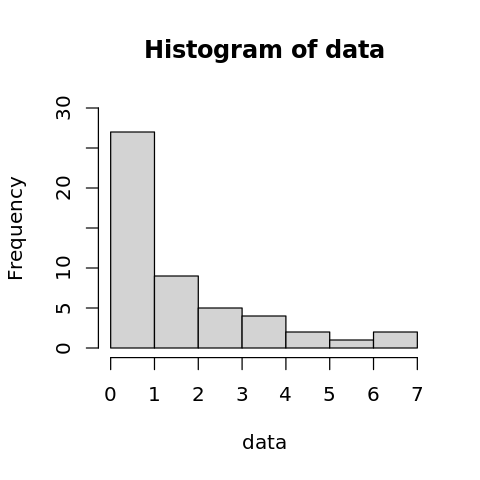

In [4]:
##
## El histograma muestra que los datos se comportan de manera 
## decreciente, centrados en su mayoría en valores entre 0 y 1.
##
options(repr.plot.width = 4, repr.plot.height = 4)
hist(data, ylim=c(0,30), col='lightgrey')

### Paso 2
El segundo paso consiste en estimar los parámetros de cada distribución a partir de los datos los datos. La estimación se puede realizar por mínimos cuadrados ordinarios, por bondad de ajuste o por máxima verosimilitud. En este documento se aborda únicamente la estimación por máxima verosimilitud, ya que es la implementada en paquetes estadísticos como el lenguaje R.

En la estimación por máxima verosimilitud se responde la siguiente pregunta: ¿Cuáles son los parámetros de la distribucion considerada para que se maximice la probabilidad de que los datos provengan de ella?.

Si se tiene un conjunto de datos $x_1$, $x_2$, ..., $x_n$, la verosimilitud se define como:

$$L(x_1, x_2, ..., x_n \;|\; \theta_1, \theta_2,...) = \prod_{i=1}^n f(x_i \;|\; \theta_1, \theta_2, ...)$$

donde $\theta_1$, $\theta_2$, ... son los parámetros desconocidos de la distribución.

Por facilidad, se acostumbra usar el $\log$ de la verosimilitud:

$$\log \; L(x_1, x_2, ..., x_n \;|\; \theta_1, \theta_2,...) = \sum_{i=1}^n \log \; f(x_i \;|\; \theta_1, \theta_2, ...)$$

El problema se reducen en encontrar el conjunto de parámetros $\theta_1$, $\theta_2$, ... que maximizan el $\log \; L$.

**Ejemplo.--** La función de densidad de probabilidad de la distribución normal es:

$$f(x_i \; | \; \mu, \sigma^2) =\frac{1}{\sigma \sqrt{2\pi}} \exp \left\{ -\frac{1}{2} \frac{(x_i-\mu)^2}{\sigma^2} \right\}$$

donde los puntos $x_i$ son conocidos y los valores de $\mu$ y $\sigma^2$ son desconocidos (se desean estimar a partir de la muestra de datos). Consecuentemente,

$$\log \; L(x_1, x_2, ..., x_n \;|\; \mu, \sigma^2) = \sum_{i=1}^n \log \; f(x_i \;|\; \mu, \sigma^2)$$

Con un poco de matemática es posible demostrar que la mejor estimación de los valores se obtiene con:

$$\mu = \frac{1}{n} \sum_{i=1}^n x_i$$ 

$$\sigma^2 = \sum_{i=1}^n \frac{1}{n} (x_i - \mu)^2$$

Es decir, el mejor estimador de la media de la distribución es la media de los datos, y el mejor estimador de la varianza de la distribución es la varianza de los datos.

El procedimiento es similar para otras distribuciones de probabilidad.

Continuando con el ejemplo numérico, los parámetros de una distribución lognormal son su media y su varianza. Estos se calcularian como la media y la varianza del logaritmo natural de los datos.

A continuación se presentan el histograma de los datos, la aproximación empírica la distribución usando funciones kernel (véase el documento sobre anaálisis exploratorio), y la función de densidad de probabilidad de las distribuciones normal y lognormal ajustadas a los datos.

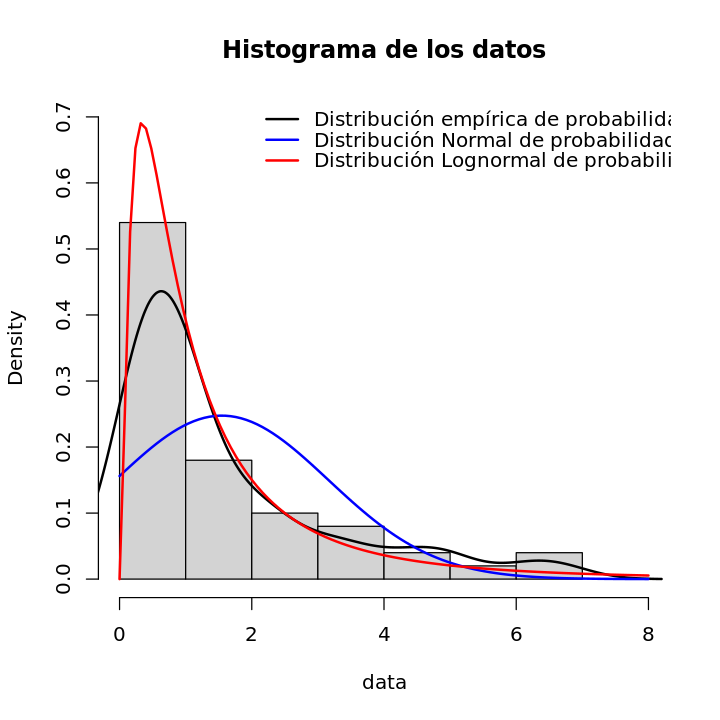

In [5]:
options(repr.plot.width = 6, repr.plot.height = 6)
##
## Histograma de los datos
##
hist(data, probability = TRUE, xlim = c(0,8), 
     ylim=c(0,0.7), main= "Histograma de los datos", col="lightgray") 

##
## Distribucióno empírica
##
lines(density(data), col='black', lwd=2)                                                                     

##
## Distribución normal
##
curve( dnorm(x,                   ## función de densidad de probabilidad
             mean = mean(data),   ## media de la gnormal estimada a partir de los datos
             sd = sd(data)),      ## desviación estándar de la normal computada a partir de los datos
      add=TRUE, col="blue", lwd=2)                          

##
## Distribución lognormal
##
curve(dlnorm(x,                      ## función de densidad de probabilidad
             mean = mean(log(data)), ## media de la lognormal estimada a partir de los datos
             sd = sd(log(data))),    ## desviación estándar de la lognormal computada a partir de los datos
      add=TRUE, col="red", lwd=2)


## demás parámetros del gráfico
legend("topright", col=c("black", "blue", "red"),
       legend =c("Distribución empírica de probabilidad",
                 "Distribución Normal de probabilidad",
                 "Distribución Lognormal de probabilidad"),
       lwd=2, bty = "n")

### Paso 3

El tercer paso consiste en seleccionar la distribución que mejor se ajusta a los datos. Para ello, se utiliza el criterio de Akaike:

$$\text{AIC} = 2k - 2 \log \;L $$

donde: $k$ es la cantidad de parámetros a estimar de la distribución y $\log\; L$ es el logaritmo natural de la verosimilitud. Se selecciona la distribución con el menor valor del criterio de Akaike.

In [6]:
##
## Se estiman los parámetros de acuerdo con la distirbución normal
## la librería MASS con la función fitdistr retorna la estimación 
## por máxima verosimilitud 
##
library(MASS)

##
## Ajuste por máxima verosimilitud para la distribución normal
##
aj_normal <- fitdistr(data,"normal")
aj_normal
confint(aj_normal)  ## Intervalos de confianza para los parámetros estimados

## La tabla indica que la media es 1.55 y la desviación estándar es 1.60.
## Los intervalos de confianza muestran que la media real de la distribución
## esta entre 1.1051 y 1.9893

     mean         sd    
  1.5472080   1.5951128 
 (0.2255830) (0.1595113)

,2.5 %,97.5 %
mean,1.105073,1.989343
sd,1.282476,1.907749


In [7]:
##
## Máxima verosimilitud para la distribución lognormal
##
aj_lnormal <- fitdistr(data,"lognormal")
aj_lnormal
confint(aj_lnormal) ## Intervalos de confianza para los parámetros estimados

## Esta tabla se lee igual que la anterior.

     meanlog        sdlog   
  -0.04970888    1.00549261 
 ( 0.14219813) ( 0.10054926)

,2.5 %,97.5 %
meanlog,-0.3284121,0.2289943
sdlog,0.8084197,1.2025655


In [8]:
##
## Prueba de bondad de ajuste para la distribución normal. En esta
## prueba:
##  
##   Ho: los datos provienen de una distribución normal
##   Ha: los datos NO provienen de una distribución normal
##
## 
## Para el valor-p de 0.009104, se rechaza la hipótesis nula. 
## Es decir, los datos no provienen de una distribución normal.
##
library(goftest) 
ad.test(data,"pnorm",mean =aj_normal$estimate[1], sd= aj_normal$estimate[2])


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: Normal distribution
	with parameters mean = 1.547208, sd = 1.59511277730949

data:  data
An = 3.9702, p-value = 0.009104


In [9]:
##
## Prueba de bondad de ajuste para la distribución lognormal. En este
## caso:
##
##   Ho: los datos provienen de una distribución lognormal
##   Ha: los datos NO provienen de una distribución lognormal
##
## Se acepta Ho ya que el valor-p es 0.9558
##
ad.test(data,"plnorm",mean =aj_lnormal$estimate[1], sd= aj_lnormal$estimate[2])


	Anderson-Darling test of goodness-of-fit
	Null hypothesis: log-normal distribution

data:  data
An = 0.27457, p-value = 0.9558


Como conclusión podría descartarse la distribución normal, pero se continuará considerando para ejemplificar el resto del proceso. En la práctica se tienen más de dos distribuciones posibles; las pruebas de bondad de ajuste permiten descartar algunas de las distribuciones consideradas.

In [11]:
##
## Se calcula el AIC para determinar la mejor distribución de probabilidad.
## Con un AIC de 141,47, la distribución lognormal se considera la que mejor
## se ajusta a los datos.
##
cat('AIC Normal    =',AIC(aj_normal),'\n')
cat('AIC Lognormal =',AIC(aj_lnormal),' ')

AIC Normal    = 192.5883 
AIC Lognormal = 141.4707  

---